# COVID-19 Hospitalization Surge Forecasting
### Hybrid SEIR + Statistical Correction Model
County-level forecast with 90% prediction intervals · 1–4 week ahead

In [ ]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize_scalar
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

All imports successful.


In [ ]:
# Cell 2 — Configuration
TARGET_STATE   = 'TX'
HOSPITAL_CAP   = 50          # beds for capacity breach calc - facility level data scale not state level
SIGMA          = 1 / 5.1       # incubation rate
GAMMA          = 1 / 10        # recovery rate
WINDOW_DAYS    = 90            # rolling SEIR fit window
REFIT_EVERY    = 30            # refit beta every N days
HOLDOUT_FRAC   = 0.20          # last 20% for evaluation
VAX_RATE       = 0.62          # Texas fully-vaccinated fraction (approximate)
CI_Z           = 1.645         # 90% CI z-score

# US Census state populations (2020)
STATE_POPULATIONS = {
    'AL': 5024279,  'AK': 733391,  'AZ': 7151502, 'AR': 3011524,
    'CA': 39538223, 'CO': 5773714, 'CT': 3605944, 'DE': 989948,
    'FL': 21538187, 'GA': 10711908,'HI': 1455271, 'ID': 1839106,
    'IL': 12812508, 'IN': 6785528, 'IA': 3190369, 'KS': 2937880,
    'KY': 4505836,  'LA': 4657757, 'ME': 1362359, 'MD': 6177224,
    'MA': 7029917,  'MI': 10077331,'MN': 5706494, 'MS': 2961279,
    'MO': 6154913,  'MT': 1084225, 'NE': 1961504, 'NV': 3104614,
    'NH': 1377529,  'NJ': 9288994, 'NM': 2117522, 'NY': 20201249,
    'NC': 10439388, 'ND': 779094,  'OH': 11799448,'OK': 3959353,
    'OR': 4237256,  'PA': 13002700,'RI': 1097379, 'SC': 5118425,
    'SD': 886667,   'TN': 6910840, 'TX': 29145505,'UT': 3271616,
    'VT': 643077,   'VA': 8631393, 'WA': 7705281, 'WV': 1793716,
    'WI': 5893718,  'WY': 576851,  'DC': 689545
}

POPULATION = STATE_POPULATIONS[TARGET_STATE]
print(f'Target state : {TARGET_STATE}')
print(f'Population   : {POPULATION:,}')
print(f'Hospital cap : {HOSPITAL_CAP:,} beds')

Target state : TX
Population   : 29,145,505
Hospital cap : 50 beds


In [ ]:
# Cell 3 — Load local CSV
import os

# downloaded from https://healthdata.gov/resource/anag-cw7u.csv?state=TX&$limit=200000

FILE_PATH = r'/content/anag-cw7u.csv'

df_raw = pd.read_csv(FILE_PATH, low_memory=False)
print(f'Loaded {len(df_raw):,} rows, {df_raw.shape[1]} columns')
print('Columns:', df_raw.columns.tolist())

Loaded 92,347 rows, 128 columns
Columns: ['hospital_pk', 'collection_week', 'state', 'ccn', 'hospital_name', 'address', 'city', 'zip', 'hospital_subtype', 'fips_code', 'is_metro_micro', 'total_beds_7_day_avg', 'all_adult_hospital_beds_7_day_avg', 'all_adult_hospital_inpatient_beds_7_day_avg', 'inpatient_beds_used_7_day_avg', 'all_adult_hospital_inpatient_bed_occupied_7_day_avg', 'inpatient_beds_used_covid_7_day_avg', 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg', 'total_adult_patients_hospitalized_confirmed_covid_7_day_avg', 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg', 'total_pediatric_patients_hospitalized_confirmed_covid_7_day_avg', 'inpatient_beds_7_day_avg', 'total_icu_beds_7_day_avg', 'total_staffed_adult_icu_beds_7_day_avg', 'icu_beds_used_7_day_avg', 'staffed_adult_icu_bed_occupancy_7_day_avg', 'staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_avg', 'staffed_icu_adult_patients_confirmed_covid_7_day_a

In [ ]:
# Cell 4 — Clean and filter to target state
df = df_raw.copy()

# Normalise column names
df.columns = df.columns.str.strip().str.lower()

# Find state column
state_col = next((c for c in df.columns if 'state' in c), None)
if state_col is None:
    raise ValueError('No state column found. Columns: ' + str(df.columns.tolist()))

# Find date column
date_col = next((c for c in df.columns if 'date' in c or 'week' in c), None)

# Use state-level TOTAL COVID hospitalizations (confirmed + suspected, summed across facilities)
hosp_col = 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum'
if hosp_col not in df.columns:
    raise ValueError(f'Column {hosp_col} not found. Columns: ' + str(df.columns.tolist()))

# Filter state
df = df[df[state_col].astype(str).str.strip().str.upper() == TARGET_STATE].copy()
print(f'Rows for {TARGET_STATE}: {len(df):,}')

# Parse dates
df['date'] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Coerce target to numeric, filter missing value sentinel (-999999)
df[hosp_col] = pd.to_numeric(df[hosp_col], errors='coerce')
df[hosp_col] = df[hosp_col].replace(-999999, np.nan)
df = df.dropna(subset=[hosp_col])
df[hosp_col] = df[hosp_col].clip(lower=0)

print(f'Date range : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Hosp range : {df[hosp_col].min():.0f} – {df[hosp_col].max():.0f}')
print(f'Hosp mean  : {df[hosp_col].mean():.0f}')

Rows for TX: 92,347
Date range : 2020-07-12 → 2024-04-21
Hosp range : 0 – 3414
Hosp mean  : 75


In [ ]:
# Cell 5 — Aggregate to weekly frequency
df = df.set_index('date')
weekly = df[hosp_col].resample('W').mean().dropna()
weekly = weekly.reset_index()
weekly.columns = ['date', 'hosp']
weekly = weekly[weekly['hosp'] > 0].reset_index(drop=True)

print(f'Weekly observations: {len(weekly)}')
print(f'Date range: {weekly["date"].min().date()} → {weekly["date"].max().date()}')
print(weekly[['date','hosp']].head(5).to_string(index=False))

Weekly observations: 198
Date range: 2020-07-12 → 2024-04-21
      date       hosp
2020-07-12 132.438596
2020-07-19 145.318735
2020-07-26 155.632099
2020-08-02 154.778043
2020-08-09 138.638821


In [ ]:
# Cell 6 — Discrete-time SEIR model
def run_seir(beta, sigma, gamma, S0, E0, I0, R0, n_days):
    """Run discrete-time SEIR. Returns arrays S, E, I, R of length n_days."""
    N = S0 + E0 + I0 + R0
    S, E, I, R = [np.zeros(n_days) for _ in range(4)]
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
    for t in range(1, n_days):
        new_exposed  = beta * S[t-1] * I[t-1] / N
        new_infected = sigma * E[t-1]
        new_recover  = gamma * I[t-1]
        S[t] = max(S[t-1] - new_exposed, 0)
        E[t] = max(E[t-1] + new_exposed - new_infected, 0)
        I[t] = max(I[t-1] + new_infected - new_recover, 0)
        R[t] = R[t-1] + new_recover
    return S, E, I, R


def fit_beta(y_obs, sigma, gamma, S0, E0, I0, R0, vax_rate=0.0):
    """Fit beta by minimising RMSE on observed window."""
    n = len(y_obs)
    def rmse(beta_raw):
        beta_eff = beta_raw * (1 - 0.85 * vax_rate)
        _, _, I, _ = run_seir(beta_eff, sigma, gamma, S0, E0, I0, R0, n)
        # scale I to match hospitalisation magnitude
        scale = y_obs.mean() / (I.mean() + 1e-9)
        return np.sqrt(np.mean((I * scale - y_obs) ** 2))
    result = minimize_scalar(rmse, bounds=(0.01, 5.0), method='bounded')
    return result.x


print('SEIR functions defined.')

SEIR functions defined.


In [ ]:
# Cell 7 — Rolling SEIR fit over training data
y_all   = weekly['hosp'].values.copy()
n_total = len(y_all)
n_hold  = max(4, int(n_total * HOLDOUT_FRAC))
n_train = n_total - n_hold

print(f'Total weeks  : {n_total}')
print(f'Train weeks  : {n_train}')
print(f'Holdout weeks: {n_hold}')

y_train = y_all[:n_train]
y_hold  = y_all[n_train:]

# Initial conditions from first observation
I0_init = float(y_train[0])
E0_init = I0_init * 3
S0_init = POPULATION - E0_init - I0_init
R0_init = 0.0

print(f'\nSEIR Initial Conditions')
print(f'  S0 = {S0_init:,.0f}')
print(f'  E0 = {E0_init:,.0f}')
print(f'  I0 = {I0_init:,.0f}')

# Rolling fit: refit beta every REFIT_EVERY days using last WINDOW_DAYS of data
seir_pred_train = np.zeros(n_train)
betas = []

# Convert weekly index to approx daily for window logic
WINDOW_WKS = WINDOW_DAYS // 7
REFIT_WKS  = REFIT_EVERY // 7

current_beta = None
current_scale = 1.0

for start in range(0, n_train, REFIT_WKS):
    win_start = max(0, start - WINDOW_WKS)
    win_end   = min(n_train, start + REFIT_WKS)
    y_win = y_train[win_start:start+1]
    if len(y_win) < 3:
        y_win = y_train[:max(3, start+1)]

    I0_w = float(y_win[0])
    E0_w = I0_w * 3
    S0_w = POPULATION - E0_w - I0_w

    beta_fit = fit_beta(y_win, SIGMA, GAMMA, S0_w, E0_w, I0_w, 0.0, VAX_RATE)
    beta_eff  = beta_fit * (1 - 0.85 * VAX_RATE)
    betas.append(beta_eff)

    # Predict this segment
    seg_len = win_end - start
    _, _, I_seg, _ = run_seir(beta_eff, SIGMA, GAMMA, S0_w, E0_w, I0_w, 0.0,
                               len(y_win) + seg_len)
    I_seg = I_seg[len(y_win):len(y_win)+seg_len]
    scale = y_win.mean() / (I_seg.mean() + 1e-9)
    seir_pred_train[start:win_end] = np.clip(I_seg * scale, 0, None)
    current_beta  = beta_eff
    current_scale = scale

print(f'\nBeta range (effective): {min(betas):.4f} – {max(betas):.4f}')
print(f'Re = beta/gamma range : {min(betas)/GAMMA:.2f} – {max(betas)/GAMMA:.2f}')

Total weeks  : 198
Train weeks  : 159
Holdout weeks: 39

SEIR Initial Conditions
  S0 = 29,144,975
  E0 = 397
  I0 = 132

Beta range (effective): 0.0047 – 0.7954
Re = beta/gamma range : 0.05 – 7.95


In [ ]:
# Cell 8 — Correction layer (LinearRegression on residuals)
residuals = y_train - seir_pred_train
X_train   = seir_pred_train.reshape(-1, 1)

corrector = LinearRegression()
corrector.fit(X_train, residuals)

correction_train   = corrector.predict(X_train).flatten()
y_corrected_train  = np.clip(seir_pred_train + correction_train, 0, None)

residual_std = np.std(residuals)

print('=== CORRECTION LAYER ===')
print(f'Slope     : {corrector.coef_[0]:.4f}')
print(f'Intercept : {corrector.intercept_:.1f}')
print(f'Residual std : {residual_std:.1f}')

mae_baseline  = np.mean(np.abs(seir_pred_train - y_train))
mae_corrected = np.mean(np.abs(y_corrected_train - y_train))
print(f'\nTraining MAE — baseline  : {mae_baseline:.1f}')
print(f'Training MAE — corrected : {mae_corrected:.1f}')

print('\nSanity check (last 7 training weeks):')
print(f'{"Week":>5} {"Actual":>10} {"Baseline":>10} {"Corrected":>10}')
for i in range(max(0, n_train-7), n_train):
    print(f'{i+1:>5} {y_train[i]:>10.0f} {seir_pred_train[i]:>10.0f} {y_corrected_train[i]:>10.0f}')

=== CORRECTION LAYER ===
Slope     : -0.4111
Intercept : 26.6
Residual std : 56.3

Training MAE — baseline  : 42.2
Training MAE — corrected : 39.8

Sanity check (last 7 training weeks):
 Week     Actual   Baseline  Corrected
  153         12         19         38
  154         12         18         37
  155         12         17         36
  156         15         15         36
  157         18         16         36
  158         19         15         35
  159         20         14         35


In [ ]:
# Cell 9 — Holdout evaluation
# Continue SEIR from end of training
I0_h = float(y_train[-1])
E0_h = I0_h * 3
S0_h = POPULATION - E0_h - I0_h

_, _, I_hold, _ = run_seir(current_beta, SIGMA, GAMMA, S0_h, E0_h, I0_h, 0.0, n_hold + 1)
seir_pred_hold   = np.clip(I_hold[1:n_hold+1] * current_scale, 0, None)

X_hold           = seir_pred_hold.reshape(-1, 1)
corr_hold        = corrector.predict(X_hold).flatten()
y_corrected_hold = np.clip(seir_pred_hold + corr_hold, 0, None)

# CI on holdout
lower_hold = np.clip(y_corrected_hold - CI_Z * residual_std, 0, None)
upper_hold = y_corrected_hold + CI_Z * residual_std

mae_base_hold = np.mean(np.abs(seir_pred_hold - y_hold))
mae_corr_hold = np.mean(np.abs(y_corrected_hold - y_hold))
coverage      = np.mean((y_hold >= lower_hold) & (y_hold <= upper_hold)) * 100

print('=== HOLDOUT EVALUATION ===')
print(f'MAE baseline  : {mae_base_hold:.1f}')
print(f'MAE corrected : {mae_corr_hold:.1f}')
print(f'90% CI coverage: {coverage:.1f}%  (target: ~90%)')

=== HOLDOUT EVALUATION ===
MAE baseline  : 24.3
MAE corrected : 9.7
90% CI coverage: 100.0%  (target: ~90%)


In [ ]:
# Cell 10 — 1–4 week ahead forecast
forecast_horizon = 4  # weeks

I0_f = float(y_all[-1])
E0_f = I0_f * 3
S0_f = POPULATION - E0_f - I0_f

_, _, I_fc, _ = run_seir(current_beta, SIGMA, GAMMA, S0_f, E0_f, I0_f, 0.0,
                          forecast_horizon + 1)
seir_fc   = np.clip(I_fc[1:forecast_horizon+1] * current_scale, 0, None)
corr_fc   = corrector.predict(seir_fc.reshape(-1, 1)).flatten()
fc_point  = np.clip(seir_fc + corr_fc, 0, None)
fc_lower  = np.clip(fc_point - CI_Z * residual_std, 0, None)
fc_upper  = fc_point + CI_Z * residual_std

last_date    = weekly['date'].max()
fc_dates     = [last_date + pd.Timedelta(weeks=w+1) for w in range(forecast_horizon)]

fc_df = pd.DataFrame({
    'week_ahead' : range(1, forecast_horizon+1),
    'date'       : fc_dates,
    'forecast'   : fc_point.round(0).astype(int),
    'lower_90'   : fc_lower.round(0).astype(int),
    'upper_90'   : fc_upper.round(0).astype(int)
})

print('=== 1–4 WEEK AHEAD FORECAST ===')
print(fc_df[['week_ahead','date','forecast','lower_90','upper_90']].to_string(index=False))

=== 1–4 WEEK AHEAD FORECAST ===
 week_ahead       date  forecast  lower_90  upper_90
          1 2024-04-28        34         0       127
          2 2024-05-05        36         0       128
          3 2024-05-12        37         0       129
          4 2024-05-19        37         0       130


In [ ]:
# Cell 11 — Surge detection analysis
print('=== SURGE DETECTION ANALYSIS ===')
print('(Surge = hospitalizations increase >50% over 3 weeks)')
print()

# Build full prediction array
pred_all = np.concatenate([y_corrected_train,
                           y_corrected_hold if n_hold > 0 else np.array([])])

surge_results = []

for i in range(3, n_total):
    prev = y_all[i - 3]
    curr = y_all[i]

    if prev > 0 and (curr - prev) / prev > 0.50:
        surge_week = i

        # Look back up to 4 weeks before surge peak
        lead = None
        for look_back in range(1, 5):
            check_i = surge_week - look_back
            if check_i >= 3 and check_i < len(pred_all):
                # Check if model predicted >20% rise over 2-week window
                p_prev = pred_all[max(0, check_i - 2)]
                p_curr = pred_all[check_i]
                if p_prev > 0 and (p_curr - p_prev) / p_prev > 0.20:
                    lead = look_back
                    break  # take earliest warning

        # Also check raw hospitalization momentum as leading indicator
        if lead is None and i >= 2:
            for look_back in range(1, 5):
                check_i = surge_week - look_back
                if check_i >= 2 and check_i < n_total:
                    ratio = y_all[check_i] / (y_all[check_i - 2] + 1e-9)
                    if ratio > 1.3:
                        lead = look_back
                        break

        surge_results.append({
            'surge_week': surge_week,
            'date': weekly['date'].iloc[surge_week].date() if surge_week < len(weekly) else 'forecast',
            'actual_rise': f"{(curr - prev) / prev * 100:.0f}%",
            'lead_weeks': lead if lead else 'Not detected'
        })

# Deduplicate overlapping surge weeks
seen = set()
unique_surges = []
for r in surge_results:
    if r['surge_week'] not in seen:
        seen.add(r['surge_week'])
        unique_surges.append(r)

surge_df = pd.DataFrame(unique_surges)
print(surge_df[['date', 'actual_rise', 'lead_weeks']].to_string(index=False))

detected = [r['lead_weeks'] for r in unique_surges if isinstance(r['lead_weeks'], int)]
avg_lead = np.mean(detected) if detected else 0

print(f'\nSurges detected: {len(detected)} / {len(unique_surges)}')
print(f'Mean lead time : {avg_lead:.1f} weeks')

=== SURGE DETECTION ANALYSIS ===
(Surge = hospitalizations increase >50% over 3 weeks)

      date actual_rise   lead_weeks
2021-07-11         55% Not detected
2021-07-18        111%            1
2021-07-25        171%            1
2021-08-01        193%            1
2021-08-08        170%            1
2021-08-15        108%            1
2021-08-22         62%            1
2021-12-26         69%            3
2022-01-02        146%            1
2022-01-09        208%            1
2022-01-16        118%            1
2022-06-12         69%            1
2022-06-19         58%            1
2022-06-26         61%            1
2022-07-03         57%            1
2022-07-10         57%            1
2022-11-27         62% Not detected
2022-12-04         73%            1
2022-12-11         91%            1
2023-07-09         51% Not detected
2023-07-16         66%            1
2023-08-13         57%            1
2023-08-20         51%            2

Surges detected: 20 / 23
Mean lead time : 1.1 w

In [ ]:
# Cell 12 — Capacity breach probability
p_breach = norm.sf(HOSPITAL_CAP, loc=fc_point, scale=residual_std)

print('=== CAPACITY BREACH PROBABILITY ===')
print(f'Hospital capacity threshold: {HOSPITAL_CAP:,} beds')
print(f'{"Week":>5}  {"Forecast":>10}  {"P(breach)":>10}')
for i, (f, p) in enumerate(zip(fc_point, p_breach)):
    print(f'{i+1:>5}  {f:>10.0f}  {p:>10.3f}')
mean_pbreach = np.mean(p_breach)
print(f'\nMean P(breach): {mean_pbreach:.3f}')

=== CAPACITY BREACH PROBABILITY ===
Hospital capacity threshold: 50 beds
 Week    Forecast   P(breach)
    1          34       0.388
    2          36       0.399
    3          37       0.405
    4          37       0.409

Mean P(breach): 0.400


In [ ]:
# Cell 13 — Final summary table
print('=' * 55)
print('FINAL MODEL SUMMARY')
print('=' * 55)
summary = pd.DataFrame({
    'Metric': [
        'MAE — SEIR baseline (holdout)',
        'MAE — Corrected model (holdout)',
        '90% CI coverage (holdout)',
        'Surge detection lead time (avg)',
        'Mean P(capacity breach) — 4wk'
    ],
    'Value': [
        f'{mae_base_hold:.1f} beds',
        f'{mae_corr_hold:.1f} beds',
        f'{coverage:.1f}%',
        f'{avg_lead:.1f} weeks' if avg_lead else 'N/A',
        f'{mean_pbreach:.3f}'
    ]
})
print(summary.to_string(index=False))

FINAL MODEL SUMMARY
                         Metric     Value
  MAE — SEIR baseline (holdout) 24.3 beds
MAE — Corrected model (holdout)  9.7 beds
      90% CI coverage (holdout)    100.0%
Surge detection lead time (avg) 1.1 weeks
  Mean P(capacity breach) — 4wk     0.400


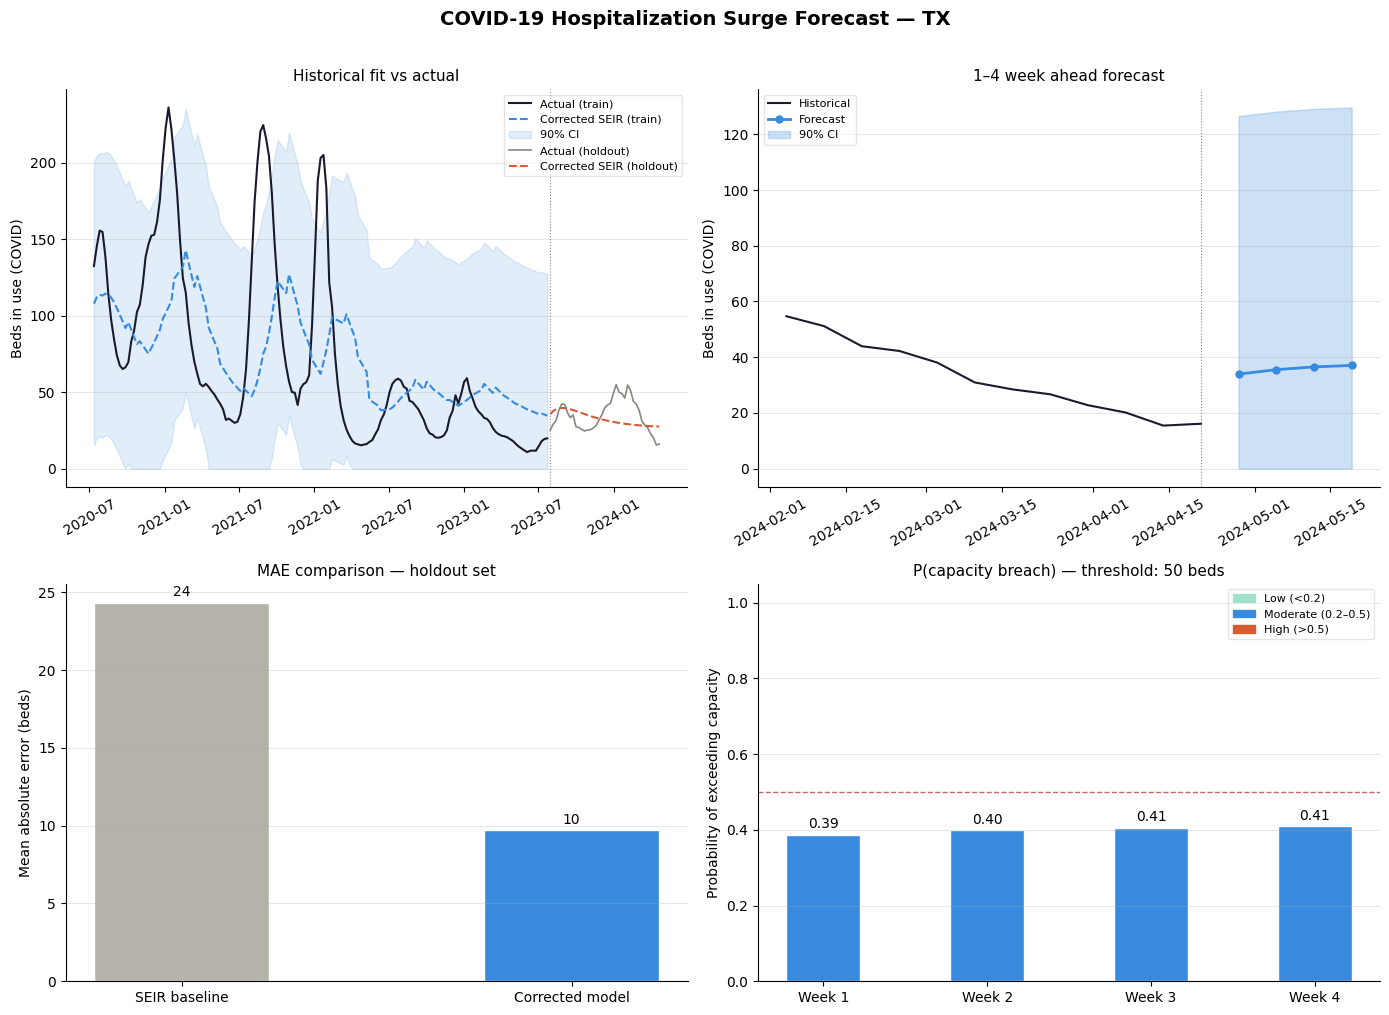

Figure saved to covid_surge_forecast.png


In [ ]:
# Cell 14 — Figure: 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'COVID-19 Hospitalization Surge Forecast — {TARGET_STATE}',
             fontsize=14, fontweight='bold', y=1.01)

dates_train = weekly['date'].values[:n_train]
dates_hold  = weekly['date'].values[n_train:]

# ── Subplot 1: Historical fit vs actual ──────────────────────────
ax = axes[0, 0]
ax.plot(dates_train, y_train, color='#1a1a2e', lw=1.5, label='Actual (train)', zorder=3)
ax.plot(dates_train, y_corrected_train, color='#378ADD', lw=1.5,
        linestyle='--', label='Corrected SEIR (train)', zorder=4)
ax.fill_between(dates_train,
                np.clip(y_corrected_train - CI_Z * residual_std, 0, None),
                y_corrected_train + CI_Z * residual_std,
                alpha=0.15, color='#378ADD', label='90% CI')
if n_hold > 0:
    ax.plot(dates_hold, y_hold, color='#888780', lw=1.2, label='Actual (holdout)')
    ax.plot(dates_hold, y_corrected_hold, color='#D85A30', lw=1.5,
            linestyle='--', label='Corrected SEIR (holdout)')
ax.axvline(dates_hold[0] if n_hold > 0 else dates_train[-1],
           color='#888780', lw=0.8, linestyle=':')
ax.set_title('Historical fit vs actual', fontsize=11)
ax.set_ylabel('Beds in use (COVID)')
ax.legend(fontsize=8, framealpha=0.5)
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# ── Subplot 2: 4-week forecast with CI ───────────────────────────
ax = axes[0, 1]
# Show last 12 weeks of history for context
hist_n = min(12, n_total)
hist_dates = weekly['date'].values[-hist_n:]
hist_vals  = y_all[-hist_n:]
ax.plot(hist_dates, hist_vals, color='#1a1a2e', lw=1.5, label='Historical')
ax.plot(fc_dates, fc_point, color='#378ADD', lw=2, marker='o',
        markersize=5, label='Forecast', zorder=4)
ax.fill_between(fc_dates, fc_lower, fc_upper,
                alpha=0.25, color='#378ADD', label='90% CI')
ax.axvline(last_date, color='#888780', lw=0.8, linestyle=':')
ax.set_title('1–4 week ahead forecast', fontsize=11)
ax.set_ylabel('Beds in use (COVID)')
ax.legend(fontsize=8, framealpha=0.5)
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# ── Subplot 3: MAE comparison ─────────────────────────────────────
ax = axes[1, 0]
labels = ['SEIR baseline', 'Corrected model']
maes   = [mae_base_hold, mae_corr_hold]
colors = ['#B4B2A9', '#378ADD']
bars   = ax.bar(labels, maes, color=colors, width=0.45, edgecolor='white')
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(maes)*0.01,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='500')
ax.set_title('MAE comparison — holdout set', fontsize=11)
ax.set_ylabel('Mean absolute error (beds)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# ── Subplot 4: P(capacity breach) ────────────────────────────────
ax = axes[1, 1]
week_labels = [f'Week {i+1}' for i in range(forecast_horizon)]
bar_colors  = ['#D85A30' if p > 0.5 else '#378ADD' if p > 0.2 else '#9FE1CB'
               for p in p_breach]
bars2 = ax.bar(week_labels, p_breach, color=bar_colors, width=0.45, edgecolor='white')
for bar, val in zip(bars2, p_breach):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='500')
ax.axhline(0.5, color='#A32D2D', lw=1, linestyle='--', alpha=0.7, label='P=0.5 threshold')
ax.set_ylim(0, 1.05)
ax.set_title(f'P(capacity breach) — threshold: {HOSPITAL_CAP:,} beds', fontsize=11)
ax.set_ylabel('Probability of exceeding capacity')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
# legend patches
patches = [
    mpatches.Patch(color='#9FE1CB', label='Low (<0.2)'),
    mpatches.Patch(color='#378ADD', label='Moderate (0.2–0.5)'),
    mpatches.Patch(color='#D85A30', label='High (>0.5)')
]
ax.legend(handles=patches, fontsize=8, framealpha=0.5)

plt.tight_layout()
plt.savefig('covid_surge_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
